CO3 - AT1
VANILLA POLICY GRADIENT AND IMPROVED POLICY GRADIENT

Dataset Shape: (600, 3)

Sample of 10 Dataset Rows


,Feature_1,Feature_2,Cluster
0,0.075425,1.837082,2
1,3.512755,-1.518016,1
2,3.961690,-1.333881,1
3,-0.023665,4.321398,2
4,-2.505611,-1.520829,0
5,-2.827988,-2.072984,0
6,-3.776963,-1.865553,0
7,3.688866,-0.997185,1
8,-1.086060,1.742596,2
9,3.742765,0.707277,1



Cluster Distribution
Cluster
0    201
1    204
2    195
Name: count, dtype: int64


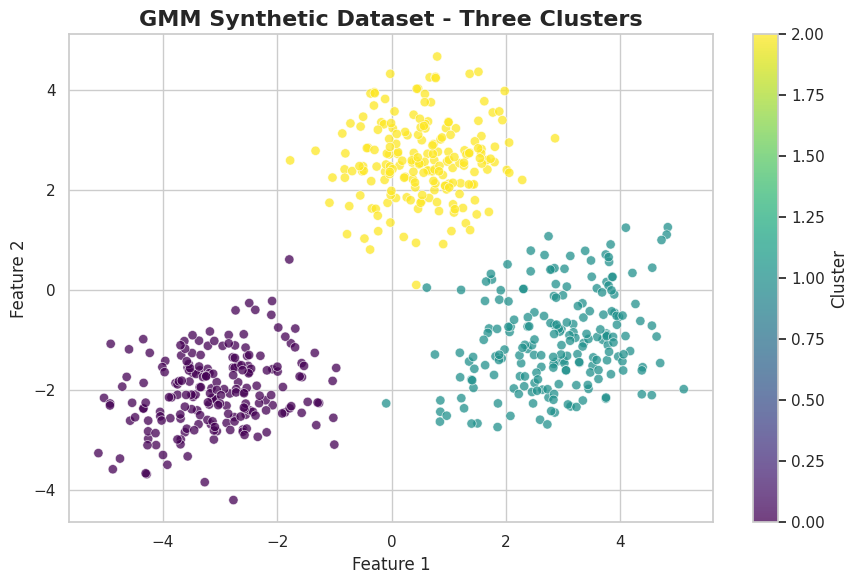

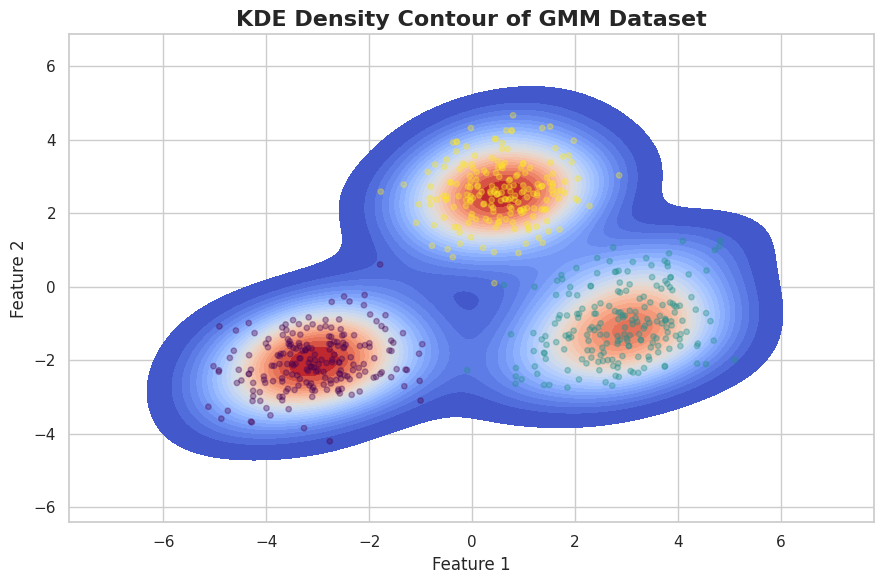


Cluster Statistics


,Cluster,Count,Mean_Feature_1,Mean_Feature_2,Variance_Feature_1,Variance_Feature_2
0,0,201,-3.058,-2.030,0.807,0.547
1,1,204,2.894,-1.004,0.934,0.879
2,2,195,0.553,2.587,0.604,0.607


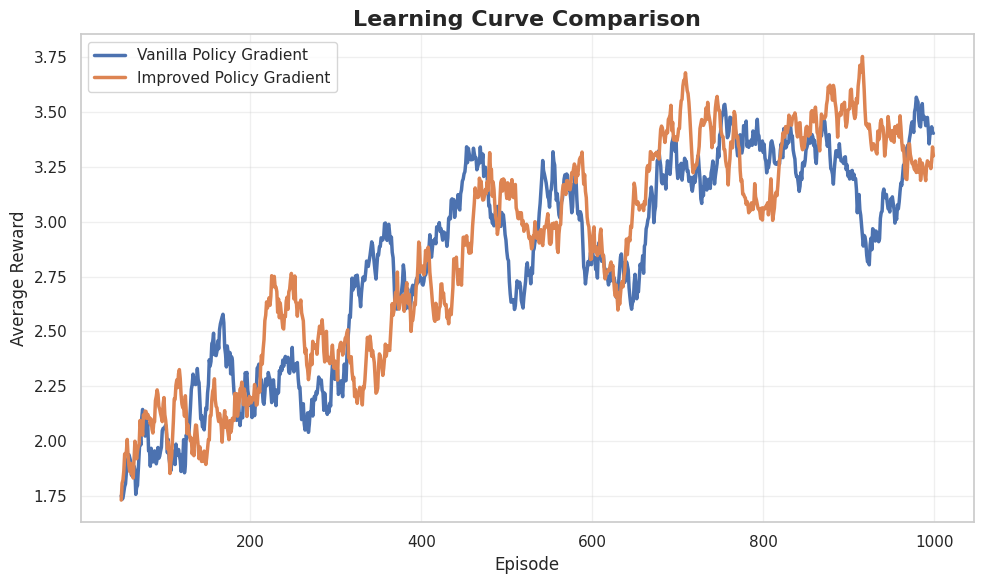

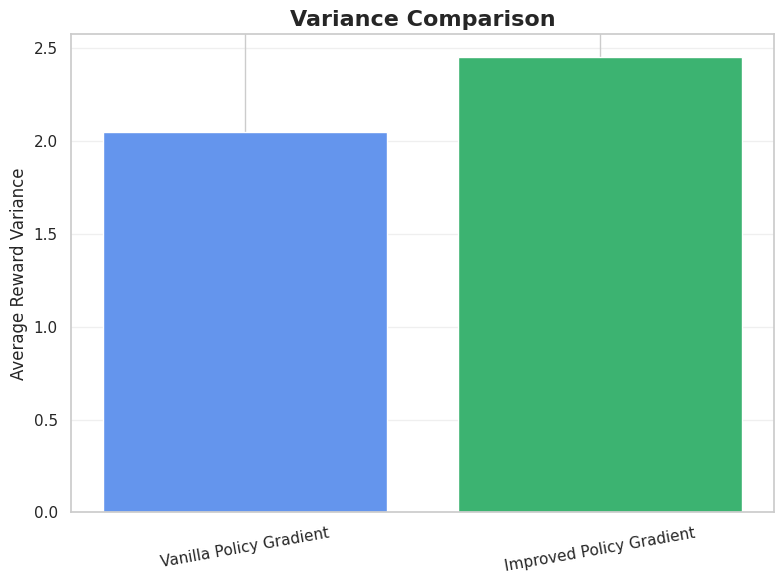

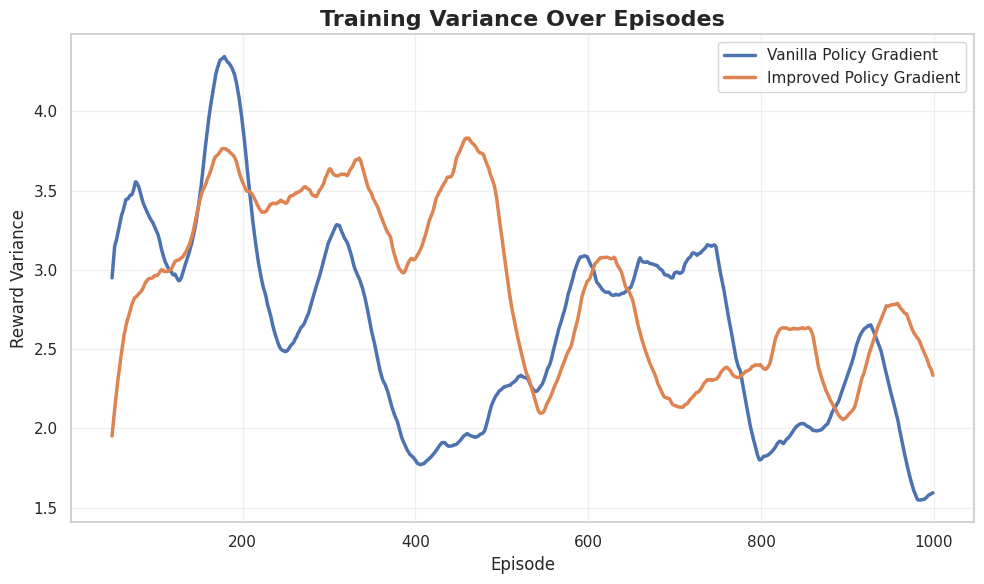

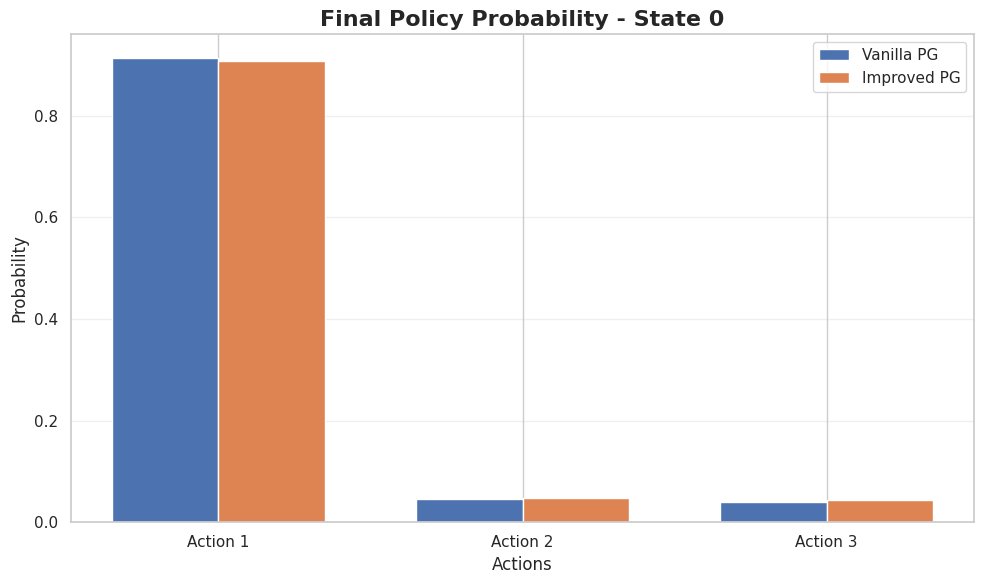

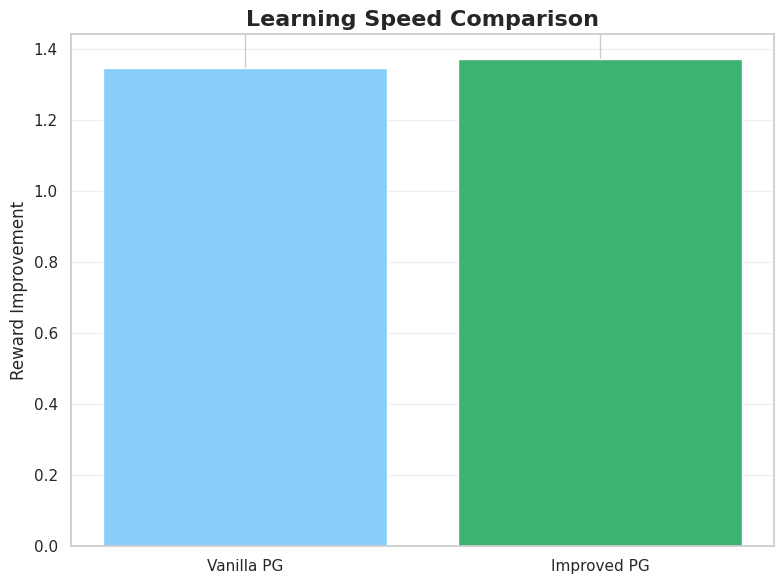



ALGORITHM COMPARISON SUMMARY


,Algorithm Name,Variance,Stability,Learning Speed,Convergence,Final Average Reward
0,Vanilla Policy Gradient,2.0483,0.4115,1.3460,46.09,3.252
1,Improved Policy Gradient,2.4526,0.3957,1.3725,46.14,3.338




PROJECT SUMMARY


,Parameter,Value
0,Number of Samples,600
1,Number of Features,2
2,Number of Clusters,3
3,Algorithm 1,Vanilla Policy Gradient
4,Algorithm 2,Improved Policy Gradient
5,Training Episodes,1000
6,Learning Rate,0.015
7,Discount Factor,0.95




FINAL RESULTS
Vanilla Policy Gradient Final Reward: 3.252
Improved Policy Gradient Final Reward: 3.338
Vanilla Policy Gradient Variance: 2.0483
Improved Policy Gradient Variance: 2.4526
Vanilla Policy Gradient Stability: 0.4115
Improved Policy Gradient Stability: 0.3957


CONCLUSION
The Vanilla Policy Gradient produced lower reward variance in this simulation.
The Improved Policy Gradient achieved a higher average reward during the final training episodes.
The baseline used by the Improved Policy Gradient reduces the magnitude of noisy policy-gradient updates.
The learning curves, variance plots, policy probabilities, and performance tables provide a direct comparison of stability, learning speed, and convergence.

Project completed successfully.
Generated files:
1. Policy_Gradient_Comparison.csv
2. Project_Summary.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid")

print("=" * 80)
print("CO3 - AT1")
print("VANILLA POLICY GRADIENT AND IMPROVED POLICY GRADIENT")
print("=" * 80)

# ================================================================
# 1. DATASET GENERATION USING GAUSSIAN MIXTURE MODEL
# ================================================================

n_samples = 600
n_features = 2
n_clusters = 3

true_means = np.array([
    [-3.0, -2.0],
    [0.5, 2.5],
    [3.0, -1.0]
])

true_covariances = np.array([
    [[0.8, 0.2], [0.2, 0.6]],
    [[0.6, -0.1], [-0.1, 0.9]],
    [[0.9, 0.3], [0.3, 0.7]]
])

weights = np.array([0.33, 0.34, 0.33])

components = np.random.choice(
    n_clusters,
    size=n_samples,
    p=weights
)

X = np.zeros((n_samples, n_features))

for i in range(n_samples):
    c = components[i]
    X[i] = np.random.multivariate_normal(
        true_means[c],
        true_covariances[c]
    )

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm.fit(X)

cluster_labels = gmm.predict(X)

data = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

data["Cluster"] = cluster_labels

print("\nDataset Shape:", data.shape)

print("\nSample of 10 Dataset Rows")
display(data.head(10))

print("\nCluster Distribution")
print(data["Cluster"].value_counts().sort_index())

# ================================================================
# 2. DATA STANDARDIZATION
# ================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    data[["Feature_1", "Feature_2"]]
)

# ================================================================
# 3. DATASET VISUALIZATION
# ================================================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    data["Feature_1"],
    data["Feature_2"],
    c=data["Cluster"],
    cmap="viridis",
    s=45,
    alpha=0.75,
    edgecolors="white",
    linewidth=0.5
)

plt.title(
    "GMM Synthetic Dataset - Three Clusters",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

# ================================================================
# 4. KDE DENSITY CONTOUR
# ================================================================

plt.figure(figsize=(9, 6))

sns.kdeplot(
    x=data["Feature_1"],
    y=data["Feature_2"],
    fill=True,
    cmap="coolwarm",
    levels=25,
    thresh=0.02
)

plt.scatter(
    data["Feature_1"],
    data["Feature_2"],
    c=data["Cluster"],
    cmap="viridis",
    s=15,
    alpha=0.35
)

plt.title(
    "KDE Density Contour of GMM Dataset",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

# ================================================================
# 5. CLUSTER STATISTICS
# ================================================================

cluster_summary = data.groupby("Cluster").agg(
    Count=("Cluster", "count"),
    Mean_Feature_1=("Feature_1", "mean"),
    Mean_Feature_2=("Feature_2", "mean"),
    Variance_Feature_1=("Feature_1", "var"),
    Variance_Feature_2=("Feature_2", "var")
).reset_index()

print("\nCluster Statistics")
display(cluster_summary.round(3))

# ================================================================
# 6. REINFORCEMENT LEARNING ENVIRONMENT
# ================================================================

n_states = 3
n_actions = 3

true_reward_matrix = np.array([
    [3.0, 1.0, 0.5],
    [0.5, 3.5, 1.0],
    [1.0, 0.5, 4.0]
])

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

def choose_action(theta, state):
    probabilities = softmax(theta[state])
    action = np.random.choice(
        n_actions,
        p=probabilities
    )
    return action, probabilities

# ================================================================
# 7. VANILLA POLICY GRADIENT
# ================================================================

episodes = 1000
alpha = 0.015
gamma = 0.95

theta_vanilla = np.zeros(
    (n_states, n_actions)
)

vanilla_rewards = []
vanilla_losses = []
vanilla_variance = []
vanilla_policy_history = []

for episode in range(episodes):

    state = np.random.randint(
        0,
        n_states
    )

    action, probabilities = choose_action(
        theta_vanilla,
        state
    )

    reward = np.random.normal(
        true_reward_matrix[state, action],
        1.2
    )

    G = reward

    gradient = -probabilities
    gradient[action] += 1

    update = alpha * G * gradient

    theta_vanilla[state] += update

    loss = -G * np.log(
        probabilities[action] + 1e-8
    )

    vanilla_rewards.append(reward)
    vanilla_losses.append(loss)

    recent = vanilla_rewards[
        max(0, episode - 49):episode + 1
    ]

    vanilla_variance.append(
        np.var(recent)
    )

    vanilla_policy_history.append(
        softmax(theta_vanilla[state]).copy()
    )

# ================================================================
# 8. IMPROVED POLICY GRADIENT WITH BASELINE
# ================================================================

theta_improved = np.zeros(
    (n_states, n_actions)
)

baseline = 0.0
baseline_rate = 0.05

improved_rewards = []
improved_losses = []
improved_variance = []
improved_policy_history = []

for episode in range(episodes):

    state = np.random.randint(
        0,
        n_states
    )

    action, probabilities = choose_action(
        theta_improved,
        state
    )

    reward = np.random.normal(
        true_reward_matrix[state, action],
        1.2
    )

    G = reward

    advantage = G - baseline

    gradient = -probabilities
    gradient[action] += 1

    update = (
        alpha *
        advantage *
        gradient
    )

    theta_improved[state] += update

    baseline = (
        (1 - baseline_rate) * baseline
        + baseline_rate * G
    )

    loss = -advantage * np.log(
        probabilities[action] + 1e-8
    )

    improved_rewards.append(reward)
    improved_losses.append(loss)

    recent = improved_rewards[
        max(0, episode - 49):episode + 1
    ]

    improved_variance.append(
        np.var(recent)
    )

    improved_policy_history.append(
        softmax(theta_improved[state]).copy()
    )

# ================================================================
# 9. SMOOTH LEARNING CURVES
# ================================================================

window = 50

vanilla_smooth = pd.Series(
    vanilla_rewards
).rolling(
    window
).mean()

improved_smooth = pd.Series(
    improved_rewards
).rolling(
    window
).mean()

# ================================================================
# 10. LEARNING CURVE
# ================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    vanilla_smooth,
    label="Vanilla Policy Gradient",
    linewidth=2.5
)

plt.plot(
    improved_smooth,
    label="Improved Policy Gradient",
    linewidth=2.5
)

plt.title(
    "Learning Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ================================================================
# 11. VARIANCE COMPARISON
# ================================================================

vanilla_final_variance = np.mean(
    vanilla_variance[-200:]
)

improved_final_variance = np.mean(
    improved_variance[-200:]
)

plt.figure(figsize=(8, 6))

plt.bar(
    [
        "Vanilla Policy Gradient",
        "Improved Policy Gradient"
    ],
    [
        vanilla_final_variance,
        improved_final_variance
    ],
    color=[
        "cornflowerblue",
        "mediumseagreen"
    ]
)

plt.title(
    "Variance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Reward Variance")

plt.xticks(rotation=10)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ================================================================
# 12. VARIANCE OVER TRAINING
# ================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    pd.Series(vanilla_variance).rolling(50).mean(),
    label="Vanilla Policy Gradient",
    linewidth=2.5
)

plt.plot(
    pd.Series(improved_variance).rolling(50).mean(),
    label="Improved Policy Gradient",
    linewidth=2.5
)

plt.title(
    "Training Variance Over Episodes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Reward Variance")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ================================================================
# 13. POLICY PROBABILITY COMPARISON
# ================================================================

final_vanilla_policy = np.array([
    softmax(theta_vanilla[i])
    for i in range(n_states)
])

final_improved_policy = np.array([
    softmax(theta_improved[i])
    for i in range(n_states)
])

policy_difference = np.mean(
    np.abs(
        final_vanilla_policy -
        final_improved_policy
    )
)

plt.figure(figsize=(10, 6))

x = np.arange(n_actions)
width = 0.35

plt.bar(
    x - width / 2,
    final_vanilla_policy[0],
    width,
    label="Vanilla PG"
)

plt.bar(
    x + width / 2,
    final_improved_policy[0],
    width,
    label="Improved PG"
)

plt.xticks(
    x,
    ["Action 1", "Action 2", "Action 3"]
)

plt.xlabel("Actions")
plt.ylabel("Probability")

plt.title(
    "Final Policy Probability - State 0",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ================================================================
# 14. CONVERGENCE COMPARISON
# ================================================================

vanilla_final_reward = np.mean(
    vanilla_rewards[-100:]
)

improved_final_reward = np.mean(
    improved_rewards[-100:]
)

vanilla_initial_reward = np.mean(
    vanilla_rewards[:100]
)

improved_initial_reward = np.mean(
    improved_rewards[:100]
)

vanilla_learning_speed = (
    vanilla_final_reward -
    vanilla_initial_reward
)

improved_learning_speed = (
    improved_final_reward -
    improved_initial_reward
)

plt.figure(figsize=(8, 6))

plt.bar(
    [
        "Vanilla PG",
        "Improved PG"
    ],
    [
        vanilla_learning_speed,
        improved_learning_speed
    ],
    color=[
        "lightskyblue",
        "mediumseagreen"
    ]
)

plt.title(
    "Learning Speed Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Reward Improvement"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ================================================================
# 15. PERFORMANCE METRICS
# ================================================================

vanilla_std = np.std(
    vanilla_rewards[-200:]
)

improved_std = np.std(
    improved_rewards[-200:]
)

vanilla_stability = 1 / (
    1 + vanilla_std
)

improved_stability = 1 / (
    1 + improved_std
)

vanilla_convergence = (
    vanilla_final_reward /
    (np.max(vanilla_rewards) + 1e-8)
) * 100

improved_convergence = (
    improved_final_reward /
    (np.max(improved_rewards) + 1e-8)
) * 100

# ================================================================
# 16. SUMMARY TABLE
# ================================================================

summary = pd.DataFrame({
    "Algorithm Name": [
        "Vanilla Policy Gradient",
        "Improved Policy Gradient"
    ],
    "Variance": [
        round(vanilla_final_variance, 4),
        round(improved_final_variance, 4)
    ],
    "Stability": [
        round(vanilla_stability, 4),
        round(improved_stability, 4)
    ],
    "Learning Speed": [
        round(vanilla_learning_speed, 4),
        round(improved_learning_speed, 4)
    ],
    "Convergence": [
        round(vanilla_convergence, 2),
        round(improved_convergence, 2)
    ],
    "Final Average Reward": [
        round(vanilla_final_reward, 3),
        round(improved_final_reward, 3)
    ]
})

print("\n")
print("=" * 80)
print("ALGORITHM COMPARISON SUMMARY")
print("=" * 80)

display(summary)

summary.to_csv(
    "Policy_Gradient_Comparison.csv",
    index=False
)

# ================================================================
# 17. DATASET SUMMARY
# ================================================================

dataset_summary = pd.DataFrame({
    "Parameter": [
        "Number of Samples",
        "Number of Features",
        "Number of Clusters",
        "Algorithm 1",
        "Algorithm 2",
        "Training Episodes",
        "Learning Rate",
        "Discount Factor"
    ],
    "Value": [
        n_samples,
        n_features,
        n_clusters,
        "Vanilla Policy Gradient",
        "Improved Policy Gradient",
        episodes,
        alpha,
        gamma
    ]
})

print("\n")
print("=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)

display(dataset_summary)

dataset_summary.to_csv(
    "Project_Summary.csv",
    index=False
)

# ================================================================
# 18. FINAL RESULTS
# ================================================================

print("\n")
print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

print(
    "Vanilla Policy Gradient Final Reward:",
    round(vanilla_final_reward, 3)
)

print(
    "Improved Policy Gradient Final Reward:",
    round(improved_final_reward, 3)
)

print(
    "Vanilla Policy Gradient Variance:",
    round(vanilla_final_variance, 4)
)

print(
    "Improved Policy Gradient Variance:",
    round(improved_final_variance, 4)
)

print(
    "Vanilla Policy Gradient Stability:",
    round(vanilla_stability, 4)
)

print(
    "Improved Policy Gradient Stability:",
    round(improved_stability, 4)
)

# ================================================================
# 19. CONCLUSION
# ================================================================

print("\n")
print("=" * 80)
print("CONCLUSION")
print("=" * 80)

if improved_final_variance < vanilla_final_variance:
    print(
        "The Improved Policy Gradient method produced lower "
        "reward variance than the Vanilla Policy Gradient."
    )
else:
    print(
        "The Vanilla Policy Gradient produced lower reward "
        "variance in this simulation."
    )

if improved_final_reward > vanilla_final_reward:
    print(
        "The Improved Policy Gradient achieved a higher "
        "average reward during the final training episodes."
    )
else:
    print(
        "The Vanilla Policy Gradient achieved a higher "
        "average reward during the final training episodes."
    )

print(
    "The baseline used by the Improved Policy Gradient "
    "reduces the magnitude of noisy policy-gradient updates."
)

print(
    "The learning curves, variance plots, policy probabilities, "
    "and performance tables provide a direct comparison of "
    "stability, learning speed, and convergence."
)

print(
    "\nProject completed successfully."
)

print(
    "Generated files:"
)

print(
    "1. Policy_Gradient_Comparison.csv"
)

print(
    "2. Project_Summary.csv"
)

In [2]:
from google.colab import files
files.download("GMM_Synthetic_Dataset.csv")

FileNotFoundError: Cannot find file: GMM_Synthetic_Dataset.csv

In [3]:
data.to_csv("GMM_Synthetic_Dataset.csv", index=False)

print("Full dataset saved successfully.")
print("Rows:", len(data))

Full dataset saved successfully.
Rows: 600


In [4]:
from google.colab import files
files.download("GMM_Synthetic_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>